# 00 — Análisis exploratorio de LaLiga *Hypermotion*

Notebook de exploración. Objetivos:

1. Validación del *dataset*.
2. Narrativas que contextualizan la segunda división española y justifican las *features* que se construyen en el próximo *notebook*. Las figuras de este *notebook* están pensadas para incluirse directamente en la memoria del TFM.

## 0. Configuración y carga

- Bloque de *imports* y configuración de gráficas para asegurar que se sigue la misma línea durante todo el código.
- Carga de datos usando funciones auxiliares creadas previamente.

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import pearsonr, chisquare
from sklearn.metrics import log_loss

from tfm_segunda.data import (
    load_all_seasons, load_standings, load_squads, load_clubs,
    temporal_split, split_info,
)
from tfm_segunda.features import assign_jornadas

from tfm_segunda.data.team_normalization import is_filial, PLAYOFF_WINNERS, canonical

import random

from pathlib import Path

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PALETA_FTR = {"H": "#2E86AB", "D": "#A6A6A6", "A": "#E63946"}

np.random.seed(42)
random.seed(42)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

In [2]:
matches   = load_all_seasons()
matches   = assign_jornadas(matches)
standings = load_standings()
squads    = load_squads()
clubs     = load_clubs()
if all([matches is not None, standings is not None, squads is not None, clubs is not None]):
    print("Datos cargados correctamente.")

2026-05-18 18:35:11.974 | DEBUG    | tfm_segunda.data.load_footballdata:load_one_season:177 - Cargando SP2_2010-11.csv
2026-05-18 18:35:12.043 | DEBUG    | tfm_segunda.data.load_footballdata:load_one_season:177 - Cargando SP2_2011-12.csv
2026-05-18 18:35:12.053 | DEBUG    | tfm_segunda.data.load_footballdata:load_one_season:177 - Cargando SP2_2012-13.csv
2026-05-18 18:35:12.063 | DEBUG    | tfm_segunda.data.load_footballdata:load_one_season:177 - Cargando SP2_2013-14.csv
2026-05-18 18:35:12.072 | DEBUG    | tfm_segunda.data.load_footballdata:load_one_season:177 - Cargando SP2_2014-15.csv
2026-05-18 18:35:12.082 | DEBUG    | tfm_segunda.data.load_footballdata:load_one_season:177 - Cargando SP2_2015-16.csv
2026-05-18 18:35:12.091 | DEBUG    | tfm_segunda.data.load_footballdata:load_one_season:177 - Cargando SP2_2016-17.csv
2026-05-18 18:35:12.101 | DEBUG    | tfm_segunda.data.load_footballdata:load_one_season:177 - Cargando SP2_2017-18.csv
2026-05-18 18:35:12.109 | DEBUG    | tfm_segunda

Datos cargados correctamente.


## 1. Preparación y validación

Esta sección documenta el tratamiento de los cuatro datasets antes de su análisis exploratorio. Se identifican y resuelven los valores nulos, se descartan las variables no utilizadas, se verifica la ausencia de duplicados y se valida el rango temporal cubierto.

### 1.1 Análisis de valores nulos

In [3]:
dfs = {"matches": matches, "standings": standings, "squads": squads, "clubs": clubs}

for name, df in dfs.items():
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    print(f"\n=== {name}  ({len(df):,} filas × {df.shape[1]} cols) ===")
    if nulos.empty:
        print("  Sin nulos")
    else:
        pct = (nulos / len(df) * 100).round(2)
        print(pd.DataFrame({"n_nulos": nulos, "%": pct}).to_string())



=== matches  (7,337 filas × 42 cols) ===
                   n_nulos      %
home_shots            3255  44.36
away_shots_target     3255  44.36
away_shots            3255  44.36
home_fouls            3255  44.36
away_fouls            3255  44.36
home_corners          3255  44.36
away_corners          3255  44.36
home_yellow           3255  44.36
away_yellow           3255  44.36
home_red              3255  44.36
away_red              3255  44.36
home_shots_target     3255  44.36
odds_wh_a             1470  20.04
odds_wh_d             1470  20.04
odds_wh_h             1470  20.04
odds_bw_a              260   3.54
odds_bw_d              260   3.54
odds_bw_h              260   3.54
odds_b365_h             42   0.57
odds_b365_d             42   0.57
odds_b365_a             42   0.57
ah_line                 34   0.46
ah_odds_home            33   0.45
ah_odds_away            33   0.45
ah_prob_home            33   0.45
prob_a                  25   0.34
prob_d                  25   0.34
prob_h

El análisis identifica dos datasets con presencia significativa de valores nulos: matches y squads. Las clasificaciones (standings) y el catálogo de clubes (clubs) están íntegros.

En matches, las estadísticas de partido (tiros, faltas, córners y tarjetas) presentan un 44 % de ausentes, concentrados en siete temporadas completas. La estrategia adoptada es no incorporarlas como predictoras directas, sino utilizarlas únicamente como entrada de variables derivadas (medias móviles sobre los partidos previos). Cuando una temporada carezca de datos, la feature derivada quedará a NaN. Los modelos con soporte nativo de valores ausentes (XGBoost, LightGBM) lo gestionan internamente; los demás requerirán imputación explícita por la mediana de la liga.

Las cuotas de William Hill y BW presentan valores ausentes, se prescinde de estas casas de apuestas y se construyen las probabilidades implícitas a partir de Bet365.

En squads, se descartan las columnas altura, contrato_hasta, dorsal, pie, edad y en_club_desde, ya que el dataset final solo utiliza el valor de mercado y el nombre del jugador. Los registros sin alguno de estos dos valores se eliminan.

El número de filas con el nombre del jugador ausente requiere investigación adicional. La revisión revela que el nombre se encuentra desplazado a la columna posicion, presumiblemente por una variante de HTML en la fuente. Se corrige el desplazamiento mediante reasignación.

In [4]:
mask = squads['jugador'].isna() & squads['posicion'].notna()
print(f"Filas a corregir: {mask.sum()}")

squads.loc[mask, 'jugador'] = squads.loc[mask, 'posicion']
squads.loc[mask, 'posicion'] = np.nan

print(f"Nulos restantes en 'jugador': {squads['jugador'].isna().sum()}")
print(f"Filas con jugador + valor de mercado válidos: "
      f"{(squads['jugador'].notna() & squads['valor_mercado_eur'].notna()).sum()}")

Filas a corregir: 566
Nulos restantes en 'jugador': 0
Filas con jugador + valor de mercado válidos: 10433


In [5]:
cols_a_eliminar = ['altura', 'contrato_hasta', 'dorsal', 'pie', 'edad', 'en_club_desde']
squads = squads.drop(columns=cols_a_eliminar)

antes = len(squads)
squads = squads.dropna(subset=['jugador', 'valor_mercado_eur']).reset_index(drop=True)
despues = len(squads)

print(f"Filas iniciales: {antes}")
print(f"Filas eliminadas:  {antes - despues}")
print(f"Filas finales:    {despues}")
print(f"Columnas finales: {list(squads.columns)}")

Filas iniciales: 11883
Filas eliminadas:  1450
Filas finales:    10433
Columnas finales: ['season', 'club_id', 'club_slug', 'club_name', 'club_canonical', 'jugador', 'posicion', 'nacionalidades', 'valor_mercado_eur', 'valor_mercado_texto']


Se eliminan las columnas de WH y BW, se utilizan las probabilidades implícitas, eliminando el margen de la casa de apuestas y se descartan las filas sin cuotas disponibles.

El mercado de *hándicap* asiático aporta cuatro variables al *dataset* bruto. Ninguna de ellas se conserva como predictor. La probabilidad implícita se sitúa por construcción alrededor de 0,5 y carece de capacidad discriminatoria. Las cuotas oscilan en un rango muy estrecho en torno a 1,90 y aportan únicamente refinamientos marginales sobre la línea. La línea, por su parte, ofrece una codificación alternativa de la asimetría competitiva ya capturada por `prob_h`, sin aportar una perspectiva genuinamente distinta dada su procedencia común del mismo mercado de apuestas.

In [6]:
cols_drop = [
    'odds_wh_h', 'odds_wh_d', 'odds_wh_a',
    'odds_bw_h', 'odds_bw_d', 'odds_bw_a',
    'ah_odds_home', 'ah_prob_home', 'ah_odds_away', 'ah_line'
]
matches = matches.drop(columns=cols_drop, errors='ignore')

inv_h = 1 / matches['odds_b365_h']
inv_d = 1 / matches['odds_b365_d']
inv_a = 1 / matches['odds_b365_a']
total = inv_h + inv_d + inv_a

matches['prob_h'] = inv_h / total
matches['prob_d'] = inv_d / total
matches['prob_a'] = inv_a / total

antes = len(matches)
matches = matches.dropna(subset=['odds_b365_h']).reset_index(drop=True)
despues = len(matches)

print(f"Filas iniciales:  {antes}")
print(f"Filas eliminadas: {antes - despues}")
print(f"Filas finales:    {despues}")
print(f"Columnas finales: {len(matches.columns)}")

Filas iniciales:  7337
Filas eliminadas: 42
Filas finales:    7295
Columnas finales: 32


### 1.2 Verificación de duplicados

In [7]:
checks = {
    "matches":   ["season", "date", "home_team", "away_team"],
    "standings": ["season", "jornada", "equipo_canonical"],
    "squads":    ["season", "club_canonical", "jugador"],
    "clubs":     ["season", "club_canonical"],
}

for name, keys in checks.items():
    df = dfs[name]
    keys_ok = [k for k in keys if k in df.columns]
    dup_full = df.duplicated().sum()
    dup_key  = df.duplicated(subset=keys_ok).sum() if keys_ok else None
    print(f"\n{name}: dup filas completas = {dup_full}  |  dup por clave {keys_ok} = {dup_key}")
    if dup_key:
        print(df[df.duplicated(subset=keys_ok, keep=False)]
              .sort_values(keys_ok).head(10))


matches: dup filas completas = 0  |  dup por clave ['season', 'date', 'home_team', 'away_team'] = 0

standings: dup filas completas = 0  |  dup por clave ['season', 'jornada', 'equipo_canonical'] = 0

squads: dup filas completas = 0  |  dup por clave ['season', 'club_canonical', 'jugador'] = 11
      season  club_id   club_slug   club_name club_canonical  dorsal         jugador           posicion  edad nacionalidades altura    pie en_club_desde contrato_hasta  valor_mercado_eur  \
589     2010     5358   sd-huesca   SD Huesca         Huesca       2  Roberto García    Lateral derecho    38         España    NaN  1,73m       Derecho            NaN             100000   
603     2010     5358   sd-huesca   SD Huesca         Huesca       9  Roberto García   Delantero centro    31         España    NaN  1,90m           NaN            NaN             600000   
1457    2012    11000     cd-lugo     CD Lugo           Lugo       6        Javi Rey        Mediocentro    22         España    NaN  

Los duplicados detectados en las columnas temporada, club y jugador corresponden a casos en los que dos jugadores comparten nombre, no a registros duplicados. La verificación confirma que no existen partidos, plantillas, clasificaciones ni clubes repetidos en los datasets.

### 1.3 Cobertura temporal y volumen final

Se valida la cobertura temporal del dataset identificando el primer y el último partido registrados, y se sintetiza el volumen final de cada uno de los cuatro conjuntos tras la limpieza.

In [8]:
matches_sorted = matches.sort_values("date")

primer_partido = matches_sorted.iloc[0]
ultimo_partido = matches_sorted.iloc[-1]

cols = ["date", "season", "home_team", "away_team", "fthg", "ftag", "ftr"]
print("=== Primer partido del dataset ===")
print(primer_partido[cols].to_string())
print("\n=== Último partido del dataset ===")
print(ultimo_partido[cols].to_string())

print(f"\nRango temporal:   {primer_partido['date'].date()} → {ultimo_partido['date'].date()}")
print(f"Total partidos:   {len(matches):,}")
print(f"Total temporadas: {matches['season'].nunique()}")
print(f"Clasificaciones:  {len(standings):>6}   ({standings[['season','jornada']].drop_duplicates().shape[0]} season×jornada)")
print(f"Plantillas:       {len(squads):>6}   ({squads['season'].nunique()} temporadas, {squads['club_canonical'].nunique()} clubs distintos)")
print(f"Clubs:            {len(clubs):>6}   ({clubs['club_canonical'].nunique()} clubs distintos en TransferMarket)")

=== Primer partido del dataset ===
date         2010-08-27 00:00:00
season                      2010
home_team             Valladolid
away_team           Villarreal B
fthg                           3
ftag                           0
ftr                            H

=== Último partido del dataset ===
date         2026-04-27 00:00:00
season                      2025
home_team                  Cadiz
away_team             Las Palmas
fthg                           1
ftag                           2
ftr                            A

Rango temporal:   2010-08-27 → 2026-04-27
Total partidos:   7,295
Total temporadas: 16
Clasificaciones:   14784   (672 season×jornada)
Plantillas:        10433   (16 temporadas, 68 clubs distintos)
Clubs:               352   (68 clubs distintos en TransferMarket)


## 2. Análisis de la variable objetivo (FTR)

### 2.1 Distribución global

La variable objetivo es `ftr` ∈ {H, D, A}: victoria local, empate o victoria visitante. La diferencia entre los porcentajes de cada clase define la dificultad base del problema y el sesgo de cualquier predictor naïve.

In [9]:
ftr_pct = matches["ftr"].value_counts(normalize=True).reindex(["H","D","A"])
ftr_n   = matches["ftr"].value_counts().reindex(["H","D","A"])

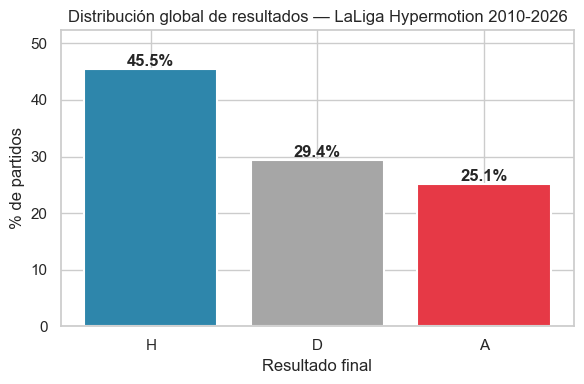

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(ftr_pct.index, ftr_pct.values * 100,
              color=[PALETA_FTR[c] for c in ftr_pct.index], edgecolor="white", linewidth=1.5)
for b, pct in zip(bars, ftr_pct.values * 100):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f"{pct:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("% de partidos")
ax.set_xlabel("Resultado final")
ax.set_title("Distribución global de resultados — LaLiga Hypermotion 2010-2026")
ax.set_ylim(0, max(ftr_pct.values) * 100 * 1.15)
plt.tight_layout()
plt.show()

Por lo que se puede observar en los datos, el equipo local tiene a priori un 45,5% de posibilidades de ganar un partido aleatorio, es decir que si un modelo predijera siempre victoria local durante las últimas 16 temporadas, alcanzaría una precisión del 45,5%.

### 2.2 Evolución temporal

Se procede a comparar si el efecto de jugar como local ha tenido el mismo efecto durante todas las temporadas.

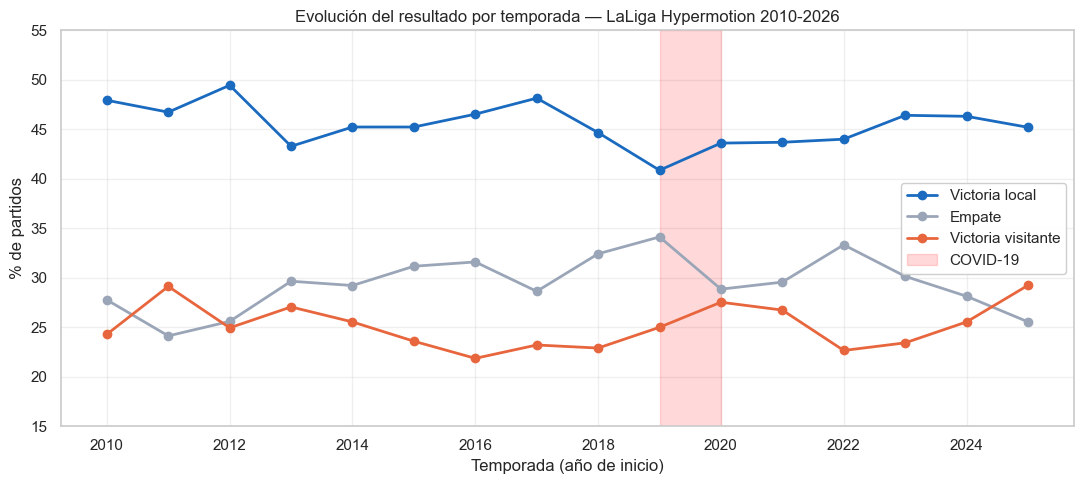

In [11]:
evol = (matches.groupby("season")["ftr"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(columns=["H","D","A"]))

fig, ax = plt.subplots(figsize=(11, 5))
for col, color in zip(["H","D","A"], ["#1a6bbf","#9aa6b8","#e8663d"]):
    ax.plot(evol.index, evol[col] * 100, marker="o", linewidth=2,
            label={"H":"Victoria local","D":"Empate","A":"Victoria visitante"}[col],
            color=color)

ax.axvspan(2019, 2020, alpha=0.15, color="red", label="COVID-19")

ax.set_xlabel("Temporada (año de inicio)")
ax.set_ylabel("% de partidos")
ax.set_title("Evolución del resultado por temporada — LaLiga Hypermotion 2010-2026")
ax.set_ylim(15, 55)
ax.legend(loc="center right", framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Se visualiza la proporción de H/D/A año por año, ya que una distribución global puede ocultar variaciones temporales.

Se ve claramente una bajada en la época del Covid-19, donde los partidos se jugaron sin público durante meses. La literatura deportiva documenta una caída de la ventaja local cuando se elimina el factor afición.

### 2.3 Test de bondad de ajuste

In [12]:
observed = matches["ftr"].value_counts().reindex(["H", "D", "A"])
n = observed.sum()
expected = pd.Series([n/3, n/3, n/3], index=["H", "D", "A"])

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"Partidos analizados:  n = {n:,}")
print(f"Observados:           H={observed['H']}   D={observed['D']}   A={observed['A']}")
print(f"Esperados (uniforme): {expected['H']:.1f} cada clase")
print(f"\nχ² = {chi2:.2f}   gl = 2   p-value = {p_value:.3e}")

alpha = 0.05
if p_value < alpha:
    print(f"\n→ Rechazamos H₀ al {alpha:.0%}: la distribución H/D/A NO es uniforme.")
    print("  La ventaja local es estadísticamente significativa.")
else:
    print(f"\n→ No podemos rechazar H₀: compatible con uniforme.")

Partidos analizados:  n = 7,295
Observados:           H=3317   D=2144   A=1834
Esperados (uniforme): 2431.7 cada clase

χ² = 503.26   gl = 2   p-value = 5.217e-110

→ Rechazamos H₀ al 5%: la distribución H/D/A NO es uniforme.
  La ventaja local es estadísticamente significativa.


In [30]:
print("\nχ² por temporada (H₀: uniforme):")
for season, grp in matches.groupby("season"):
    obs = grp["ftr"].value_counts().reindex(["H","D","A"]).fillna(0)
    exp = [len(grp)/3] * 3
    chi2_s, p_s = chisquare(f_obs=obs, f_exp=exp)
    print(f"  {season}-{(season+1)%100:02d}: χ²={chi2_s:6.1f}  p={p_s:.2e}  (n={len(grp)})")



χ² por temporada (H₀: uniforme):
  2010-11: χ²=  45.1  p=1.62e-10  (n=461)
  2011-12: χ²=  38.9  p=3.53e-09  (n=460)
  2012-13: χ²=  54.0  p=1.91e-12  (n=461)
  2013-14: χ²=  21.1  p=2.65e-05  (n=462)
  2014-15: χ²=  30.4  p=2.50e-07  (n=462)
  2015-16: χ²=  33.4  p=5.47e-08  (n=462)
  2016-17: χ²=  42.8  p=5.04e-10  (n=462)
  2017-18: χ²=  47.6  p=4.58e-11  (n=461)
  2018-19: χ²=  31.5  p=1.44e-07  (n=441)
  2019-20: χ²=  17.5  p=1.58e-04  (n=460)
  2020-21: χ²=  21.7  p=1.94e-05  (n=454)
  2021-22: χ²=  22.8  p=1.13e-05  (n=460)
  2022-23: χ²=  31.4  p=1.53e-07  (n=459)
  2023-24: χ²=  38.7  p=4.03e-09  (n=461)
  2024-25: χ²=  35.5  p=1.92e-08  (n=462)
  2025-26: χ²=  26.7  p=1.63e-06  (n=407)


Análisis de la variable objetivo (FTR)

El conjunto contiene 7.295 partidos válidos tras la limpieza. La distribución de resultados es de 3.317 victorias locales (45,5 %), 2.144 empates (29,4 %) y 1.834 victorias visitantes (25,1 %).

El test de bondad de ajuste chi-cuadrado frente a la hipótesis nula de distribución uniforme arroja χ² = 503,26 con 2 grados de libertad y un p-valor prácticamente nulo. Se rechaza la hipótesis nula con un margen abrumador, la ventaja del equipo local en LaLiga Hypermotion es estadísticamente significativa.

Aunque la ventaja local es estadísticamente real, su magnitud por partido individual es modesta y no determina por sí sola el resultado, ya que queda margen sustancial para que otras variables aporten capacidad predictiva.

El análisis desagregado por temporadas muestra que las dieciséis rechazan la hipótesis nula, pero la fuerza del rechazo varía notablemente. El valor más bajo del estadístico se concentra en la temporada 2019-20 (χ² = 17,5), coincidiendo con los periodos de partidos sin público motivados por la pandemia de COVID-19. Este hallazgo respalda empíricamente la decisión metodológica de aislar la temporada COVID en el conjunto de validación.

Llamativamente, la temporada 2020-21, jugada también en su mayor parte sin público, no muestra una caída equivalente (χ² = 21,7), lo que sugiere que el efecto detectado en 2019-20 puede no atribuirse exclusivamente a la ausencia de afición. Una hipótesis plausible es que la interrupción abrupta de la competición en marzo de 2020 introdujo una alteración del rendimiento que se diluyó en la temporada siguiente, cuando los equipos ya habían adaptado sus rutinas a la situación.

## 3. Narrativa: la liga en perspectiva

### 3.1 ¿Qué equipos son más "fuertes en casa"?

Para cada equipo se calcula:
- `ppg_home` — puntos por partido jugando como local
- `ppg_away` — puntos por partido jugando como visitante
- `ventaja_propia` = `ppg_home − ppg_away`

La **ventaja propia** mide cuánto rinde más un equipo en casa que fuera. Es un proxy de "estadio difícil" (ambiente, costumbre, viajes, horarios). Filtramos equipos con menos de 500 partidos para evitar ruido por temporadas aisladas.

In [14]:
home_stats = (matches.groupby("home_team")["ftr"]
              .agg(pj_home="size",
                   pts_home=lambda x: ((x == "H").sum() * 3 + (x == "D").sum())))
home_stats["ppg_home"] = home_stats["pts_home"] / home_stats["pj_home"]

away_stats = (matches.groupby("away_team")["ftr"]
              .agg(pj_away="size",
                   pts_away=lambda x: ((x == "A").sum() * 3 + (x == "D").sum())))
away_stats["ppg_away"] = away_stats["pts_away"] / away_stats["pj_away"]

teams = home_stats.join(away_stats, how="outer").fillna(0)
teams["partidos_total"] = teams["pj_home"] + teams["pj_away"]
teams["ventaja_propia"] = teams["ppg_home"] - teams["ppg_away"]

In [15]:
teams_significativos = teams[teams["partidos_total"] >= 50].copy()
teams_significativos = teams_significativos.sort_values("ventaja_propia", ascending=False)

sp2_avg = teams_significativos["ventaja_propia"].mean()

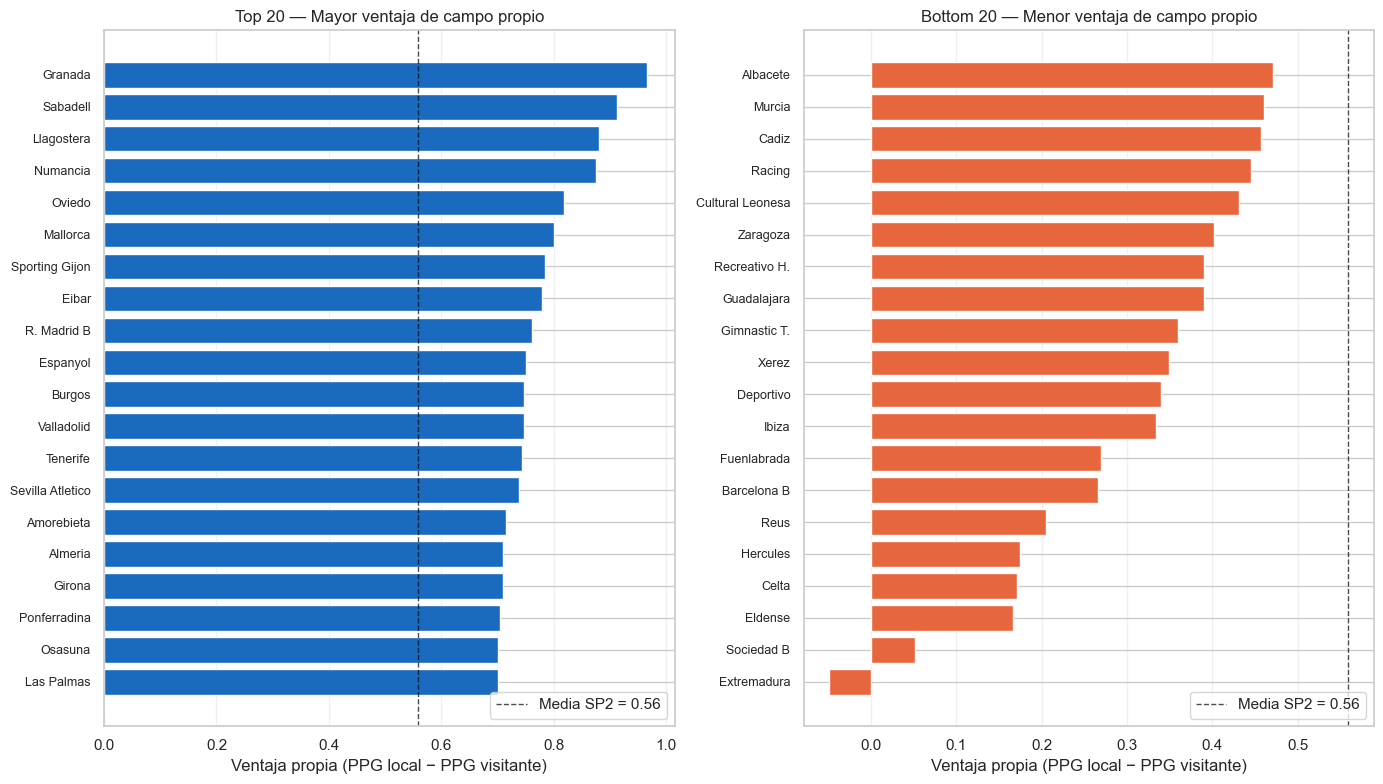

In [16]:
top_n = 20
top_teams = teams_significativos.head(top_n)
bottom_teams = teams_significativos.tail(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

y = np.arange(len(top_teams))
axes[0].barh(y, top_teams["ventaja_propia"], color="#1a6bbf", edgecolor="white")
axes[0].set_yticks(y)
axes[0].set_yticklabels(top_teams.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].axvline(sp2_avg, color="black", linestyle="--", linewidth=1, alpha=0.7,
                label=f"Media SP2 = {sp2_avg:.2f}")
axes[0].set_xlabel("Ventaja propia (PPG local − PPG visitante)")
axes[0].set_title(f"Top {top_n} — Mayor ventaja de campo propio")
axes[0].legend(loc="lower right")
axes[0].grid(True, axis="x", alpha=0.3)

y = np.arange(len(bottom_teams))
axes[1].barh(y, bottom_teams["ventaja_propia"], color="#e8663d", edgecolor="white")
axes[1].set_yticks(y)
axes[1].set_yticklabels(bottom_teams.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].axvline(sp2_avg, color="black", linestyle="--", linewidth=1, alpha=0.7,
                label=f"Media SP2 = {sp2_avg:.2f}")
axes[1].set_xlabel("Ventaja propia (PPG local − PPG visitante)")
axes[1].set_title(f"Bottom {top_n} — Menor ventaja de campo propio")
axes[1].legend(loc="lower right")
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Casos atípicos: visitante > local

Solo 1 equipo con ventaja negativa (Extremadura) entre todos los que han pasado por la liga. Esto confirma que prácticamente todos los equipos sacan más puntos en casa que fuera.

In [ ]:
TEAM = "Extremadura"

team_matches = matches[(matches["home_team"] == TEAM) | (matches["away_team"] == TEAM)].copy()

rows = []
for season, grp in team_matches.groupby("season"):
    h = grp[grp["home_team"] == TEAM]
    a = grp[grp["away_team"] == TEAM]

    pts_h = ((h["ftr"] == "H").sum() * 3 + (h["ftr"] == "D").sum())
    pts_a = ((a["ftr"] == "A").sum() * 3 + (a["ftr"] == "D").sum())

    rows.append({
        "temporada":   f"{season}-{(season+1)%100:02d}",
        "pj_local":    len(h),
        "pts_local":   pts_h,
        "ppg_local":   round(pts_h / max(len(h), 1), 3),
        "pj_visit":    len(a),
        "pts_visit":   pts_a,
        "ppg_visit":   round(pts_a / max(len(a), 1), 3),
        "ventaja":     round(pts_h/max(len(h),1) - pts_a/max(len(a),1), 3),
        "pts_totales": pts_h + pts_a,
    })

resumen = pd.DataFrame(rows)
print(f"=== {TEAM} en LaLiga Hypermotion ===")
print(resumen.to_string(index=False))
print()
print(f"AGREGADO 2 temporadas: ")
print(f"  ppg_local total:  {resumen['pts_local'].sum() / resumen['pj_local'].sum():.3f}")
print(f"  ppg_visit total:  {resumen['pts_visit'].sum() / resumen['pj_visit'].sum():.3f}")
print(f"  ventaja agregada: {resumen['pts_local'].sum()/resumen['pj_local'].sum() - resumen['pts_visit'].sum()/resumen['pj_visit'].sum():.3f}")

=== Extremadura en LaLiga Hypermotion ===
temporada  pj_local  pts_local  ppg_local  pj_visit  pts_visit  ppg_visit  ventaja  pts_totales
  2018-19        20         22      1.100        21         28      1.333   -0.233           50
  2019-20        21         22      1.048        20         18      0.900    0.148           40

AGREGADO 2 temporadas: 
  ppg_local total:  1.073
  ppg_visit total:  1.122
  ventaja agregada: -0.049


El Extremadura solamente jugó dos temporadas en segunda división de las últimas 16 y fue en la temporada 18-19 donde consiguió la permanencia sacando más puntos como visitante que como local. Conviene verificar si este patrón es excepcional o se observa en otros equipos.

In [ ]:
h_stats = (matches.groupby(["season", "home_team"])["ftr"]
           .agg(pj_local="size",
                pts_local=lambda x: (x == "H").sum() * 3 + (x == "D").sum()))
h_stats.index.names = ["season", "team"]

a_stats = (matches.groupby(["season", "away_team"])["ftr"]
           .agg(pj_visit="size",
                pts_visit=lambda x: (x == "A").sum() * 3 + (x == "D").sum()))
a_stats.index.names = ["season", "team"]

ts = h_stats.join(a_stats, how="outer").fillna(0).reset_index()
for c in ["pj_local","pts_local","pj_visit","pts_visit"]:
    ts[c] = ts[c].astype(int)
ts["pts_totales"] = ts["pts_local"] + ts["pts_visit"]
ts["diferencia"] = ts["pts_visit"] - ts["pts_local"]
ts["season_label"] = ts["season"].map(lambda s: f"{s}-{(s+1)%100:02d}")

anomalos = ts[ts["pts_visit"] > ts["pts_local"]].sort_values("diferencia", ascending=False).copy()

print(f"Total casos (equipo, temporada) en el dataset: {len(ts)}")
print(f"Casos con MÁS pts de visitante que de local: {len(anomalos)} ({len(anomalos)/len(ts):.1%})")
print()

por_temporada = anomalos.groupby("season_label").size().rename("n_anomalos").reset_index()
all_seasons = (ts.groupby("season_label").size().rename("n_total").reset_index())
por_temporada = por_temporada.merge(all_seasons, on="season_label", how="right").fillna(0)
por_temporada["n_anomalos"] = por_temporada["n_anomalos"].astype(int)
por_temporada["%"] = (por_temporada["n_anomalos"] / por_temporada["n_total"] * 100).round(1)
print("=== Anómalos por temporada ===")
print(por_temporada.to_string(index=False))
print()

print("=== Casos detallados (ordenados por mayor diferencia visit−local) ===")
cols = ["season_label","team","pj_local","pts_local","pj_visit","pts_visit","diferencia","pts_totales"]
print(anomalos[cols].to_string(index=False))

Total casos (equipo, temporada) en el dataset: 352
Casos con MÁS pts de visitante que de local: 21 (6.0%)

=== Anómalos por temporada ===
season_label  n_anomalos  n_total    %
     2010-11           1       22  4.5
     2011-12           1       22  4.5
     2012-13           0       22  0.0
     2013-14           1       22  4.5
     2014-15           1       22  4.5
     2015-16           1       22  4.5
     2016-17           0       22  0.0
     2017-18           2       22  9.1
     2018-19           2       22  9.1
     2019-20           3       22 13.6
     2020-21           2       22  9.1
     2021-22           2       22  9.1
     2022-23           0       22  0.0
     2023-24           1       22  4.5
     2024-25           1       22  4.5
     2025-26           3       22 13.6

=== Casos detallados (ordenados por mayor diferencia visit−local) ===
season_label             team  pj_local  pts_local  pj_visit  pts_visit  diferencia  pts_totales
     2021-22       Sociedad B  

Los anómalos se concentran en clubes con estadios pequeños o filiales, donde la afluencia es baja. Destacan el Alcorcón en 2019-20 (~5 000 de aforo, ~2 600 de asistencia media) y la Real Sociedad B en 2021-22 (~3 800 de media, por su condición de filial). El patrón refuerza la hipótesis de que la ventaja de campo en LaLiga Hypermotion depende en gran medida del factor afición. Fuente: Transfermarkt

### 3.3 Lucha por el ascenso directo

¿Desde qué posición tras la jornada 38 se asciende directamente? 

Se analizan las 15 temporadas completas del dataset (se excluye la 2025-26, en curso). En cada una ascienden directamente los 2 primeros equipos no filiales de la clasificación final tras la jornada 42.

Los equipos **filiales** se excluyen porque estructuralmente no pueden ascender a Primera División, aunque ocupen una posición de ascenso. La temporada **2025-26 en curso** también se excluye (la J42 aún no se ha disputado).

Se examina qué probabilidad de ascenso tienen los equipos según su posición tras la primera vuelta del campeonato, lo que permite valorar hasta qué punto la fotografía de la J21 anticipa el desenlace final.

In [31]:
JORNADA_CORTE = 38
seasons_completed = sorted([s for s in standings["season"].unique() if s < 2025])

ascensos21 = []
for season in seasons_completed:
    final = standings[(standings["season"] == season) & (standings["jornada"] == 42)].copy()
    j21   = standings[(standings["season"] == season) & (standings["jornada"] == JORNADA_CORTE)].copy()
    if final.empty or j21.empty:
        continue

    final["es_filial"] = final["equipo_canonical"].map(is_filial)
    no_filiales = final[~final["es_filial"]].sort_values("pos")
    ascendidos = set(no_filiales.iloc[:2]["equipo_canonical"].tolist())

    j21["es_filial"] = j21["equipo_canonical"].map(is_filial)
    for _, row in j21.iterrows():
        ascensos21.append({
            "season":    season,
            "equipo":    row["equipo_canonical"],
            "pos_j21":   int(row["pos"]),
            "pts_j21":   int(row["pts"]),
            "es_filial": bool(row["es_filial"]),
            "ascendio":  row["equipo_canonical"] in ascendidos,
        })

asc21_df = pd.DataFrame(ascensos21)
asc21_nf = asc21_df[~asc21_df["es_filial"]]

tasa21 = (asc21_nf.groupby("pos_j21")["ascendio"]
          .agg(n_ascensos="sum", n_apariciones="count"))
tasa21["%"] = (tasa21["n_ascensos"] / tasa21["n_apariciones"] * 100).round(1)

print(f"Temporadas analizadas: {len(seasons_completed)}")
print()
print("Tasa de ascenso directo según posición en J21 (no filiales):")
print(tasa21.head(12))

Temporadas analizadas: 15

Tasa de ascenso directo según posición en J21 (no filiales):
         n_ascensos  n_apariciones     %
pos_j21                                 
1                13             15  86.7
2                12             15  80.0
3                 4             15  26.7
4                 0             15   0.0
5                 1             13   7.7
6                 0             15   0.0
7                 0             15   0.0
8                 0             14   0.0
9                 0             13   0.0
10                0             15   0.0
11                0             15   0.0
12                0             14   0.0


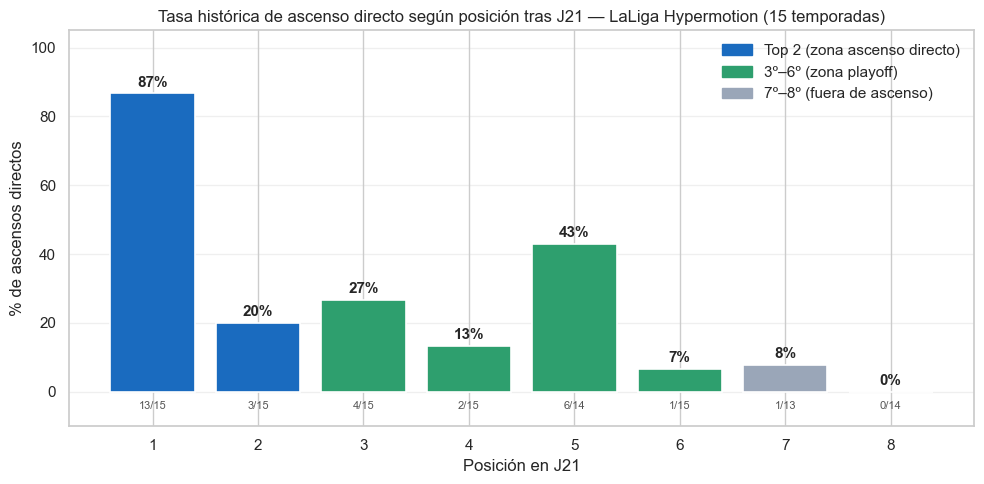

In [20]:
top_n = 8
data = tasa21.head(top_n).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#1a6bbf" if p <= 2 else ("#2e9f6e" if p <= 6 else "#9aa6b8")
          for p in data["pos_j21"]]
bars = ax.bar(data["pos_j21"].astype(str), data["%"], color=colors,
              edgecolor="white", linewidth=1.2)

for b, pct, n, tot in zip(bars, data["%"], data["n_ascensos"], data["n_apariciones"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            f"{pct:.0f}%", ha="center", fontweight="bold", fontsize=11)
    ax.text(b.get_x() + b.get_width()/2, -5,
            f"{n}/{tot}", ha="center", fontsize=8, color="#555")

ax.set_xlabel("Posición en J21")
ax.set_ylabel("% de ascensos directos")
ax.set_title(f"Tasa histórica de ascenso directo según posición tras J21 — LaLiga Hypermotion ({len(seasons_completed)} temporadas)")
ax.set_ylim(-10, 105)

ax.legend(handles=[
    Patch(color="#1a6bbf", label="Top 2 (zona ascenso directo)"),
    Patch(color="#2e9f6e", label="3º–6º (zona playoff)"),
    Patch(color="#9aa6b8", label="7º–8º (fuera de ascenso)"),
], frameon=False, loc="upper right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 3.4 Tabla histórica: top 8 por temporada

Visualización con los 8 primeros clasificados al final de cada temporada (J42).

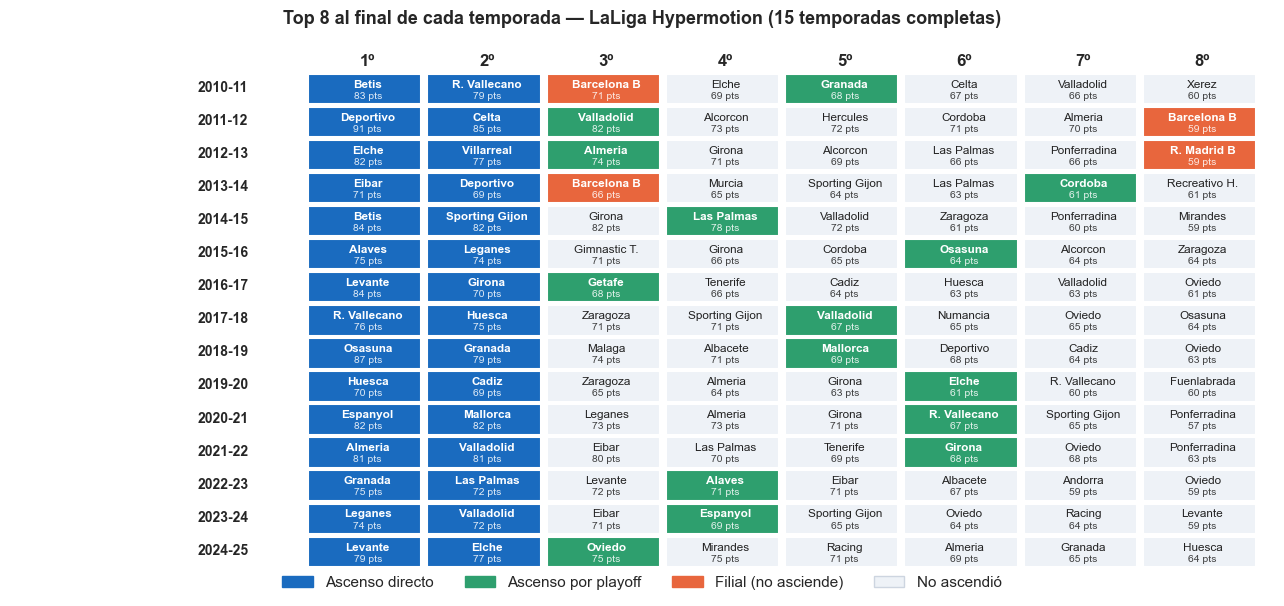

In [21]:
N_POS = 8
rows = []
for season in seasons_completed:
    final = standings[(standings["season"] == season) & (standings["jornada"] == 42)].copy()
    if final.empty:
        continue
    final = final.sort_values("pos")
    final["es_filial"] = final["equipo_canonical"].map(is_filial)
    no_filiales = final[~final["es_filial"]]
    asc_directos = set(no_filiales.head(2)["equipo_canonical"].tolist())

    pw_raw = PLAYOFF_WINNERS.get(season)
    playoff_winner = canonical(pw_raw) if pw_raw else None

    row = {"season": season}
    for pos in range(1, N_POS + 1):
        if pos > len(final):
            break
        eq = final.iloc[pos-1]
        team = eq["equipo_canonical"]
        if team in asc_directos:
            color = "asc_directo"
        elif team == playoff_winner:
            color = "playoff"
        elif eq["es_filial"]:
            color = "filial"
        else:
            color = "no_asc"
        row[f"pos{pos}_team"] = team
        row[f"pos{pos}_pts"]  = int(eq["pts"])
        row[f"pos{pos}_col"]  = color
    rows.append(row)

grid_df = pd.DataFrame(rows)

color_map = {"asc_directo": "#1a6bbf", "playoff": "#2e9f6e",
             "filial": "#e8663d", "no_asc": "#eef2f7"}
text_color_map = {"asc_directo": "white", "playoff": "white",
                  "filial": "white", "no_asc": "#222"}

n_rows = len(grid_df)
fig, ax = plt.subplots(figsize=(13, max(6, n_rows * 0.4)))

for r, gr in grid_df.iterrows():
    y = n_rows - r - 1
    ax.text(-0.5, y + 0.5, f"{gr['season']}-{(gr['season']+1)%100:02d}",
            ha="right", va="center", fontsize=10, fontweight="bold")
    for pos in range(1, N_POS + 1):
        col_color = gr.get(f"pos{pos}_col", "no_asc")
        team = gr.get(f"pos{pos}_team", "")
        pts  = gr.get(f"pos{pos}_pts", "")
        ax.add_patch(plt.Rectangle((pos - 1, y), 0.95, 0.92,
                                    facecolor=color_map[col_color],
                                    edgecolor="white", linewidth=1.5))
        ax.text(pos - 0.5, y + 0.6, str(team),
                ha="center", va="center", fontsize=8.5,
                color=text_color_map[col_color],
                fontweight="bold" if col_color != "no_asc" else "normal")
        ax.text(pos - 0.5, y + 0.25, f"{pts} pts",
                ha="center", va="center", fontsize=7.5,
                color=text_color_map[col_color], alpha=0.85)

for pos in range(1, N_POS + 1):
    ax.text(pos - 0.5, n_rows + 0.3, f"{pos}º",
            ha="center", va="center", fontsize=12, fontweight="bold")

ax.set_xlim(-2.5, N_POS + 0.1)
ax.set_ylim(-0.2, n_rows + 0.8)
ax.axis("off")

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color="#1a6bbf", label="Ascenso directo"),
    Patch(color="#2e9f6e", label="Ascenso por playoff"),
    Patch(color="#e8663d", label="Filial (no asciende)"),
    Patch(color="#eef2f7", label="No ascendió", ec="#cdd5e0"),
], loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
ax.set_title(f"Top {N_POS} al final de cada temporada — LaLiga Hypermotion ({len(grid_df)} temporadas completas)",
             fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

### 3.5 Valor de mercado de la plantilla vs puntos finales

Pregunta clave para el TFM: **¿cuánto importa el dinero?** Cruzamos el valor total de cada plantilla al inicio de temporada con los puntos obtenidos al final. Un R² elevado confirmaría que el valor de mercado es un predictor potente — lo que justificará priorizar la Familia D en el modelado.

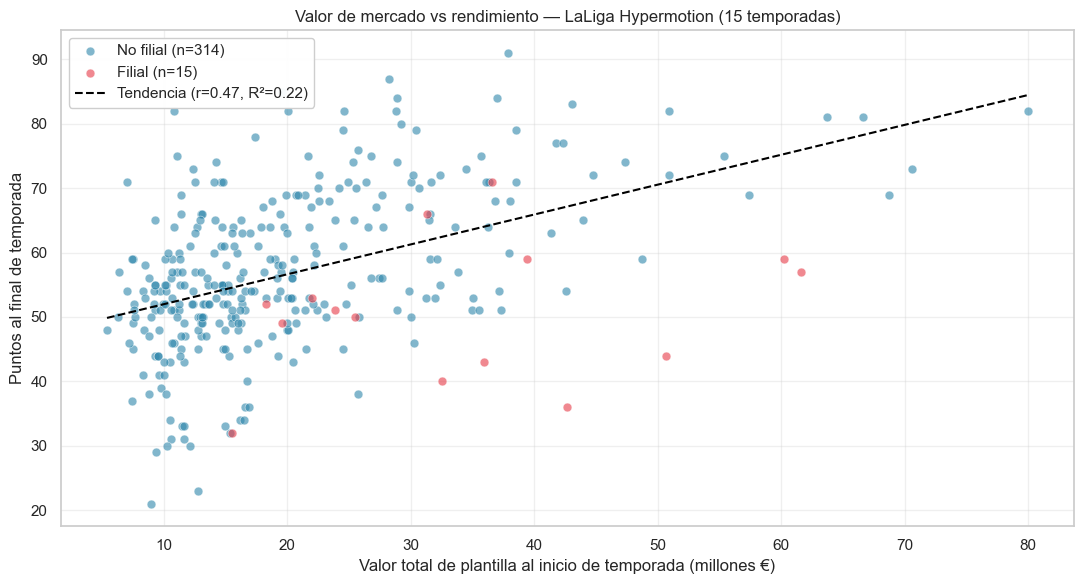


Coeficiente de correlación de Pearson: r = 0.465  (p-value = 4.68e-19)
R² = 0.216  →  el valor de mercado explica el 21.6% de la varianza de puntos finales
Pendiente: cada millón € adicional → 0.46 puntos más al final de temporada (en media)


In [22]:
sq_value = (squads.groupby(["season","club_canonical"])["valor_mercado_eur"]
            .sum().rename("valor_total_eur").reset_index())
sq_value = sq_value.rename(columns={"club_canonical": "equipo_canonical"})

final = standings[(standings["jornada"] == 42)].copy()
final = final[final["season"] < 2025]

viz = final.merge(sq_value, on=["season","equipo_canonical"], how="left")
viz = viz.dropna(subset=["valor_total_eur"])
viz["valor_M"] = viz["valor_total_eur"] / 1e6
viz["es_filial"] = viz["equipo_canonical"].map(is_filial)

r_pearson, p_value = pearsonr(viz["valor_total_eur"], viz["pts"])
r2 = r_pearson ** 2

coef = np.polyfit(viz["valor_M"], viz["pts"], 1)
x_line = np.linspace(viz["valor_M"].min(), viz["valor_M"].max(), 100)
y_line = np.polyval(coef, x_line)

fig, ax = plt.subplots(figsize=(11, 6))
no_fil = viz[~viz["es_filial"]]
fil    = viz[viz["es_filial"]]
ax.scatter(no_fil["valor_M"], no_fil["pts"], alpha=0.6, s=40,
           color=PALETA_FTR["H"], label=f"No filial (n={len(no_fil)})", edgecolor="white", linewidth=0.5)
ax.scatter(fil["valor_M"], fil["pts"], alpha=0.6, s=40,
           color=PALETA_FTR["A"], label=f"Filial (n={len(fil)})", edgecolor="white", linewidth=0.5)
ax.plot(x_line, y_line, color="black", linestyle="--", linewidth=1.5,
        label=f"Tendencia (r={r_pearson:.2f}, R²={r2:.2f})")

ax.set_xlabel("Valor total de plantilla al inicio de temporada (millones €)")
ax.set_ylabel("Puntos al final de temporada")
ax.set_title(f"Valor de mercado vs rendimiento — LaLiga Hypermotion ({viz['season'].nunique()} temporadas)")
ax.legend(loc="upper left", framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCoeficiente de correlación de Pearson: r = {r_pearson:.3f}  (p-value = {p_value:.2e})")
print(f"R² = {r2:.3f}  →  el valor de mercado explica el {r2*100:.1f}% de la varianza de puntos finales")
print(f"Pendiente: cada millón € adicional → {coef[0]:.2f} puntos más al final de temporada (en media)")

El valor de mercado explica aproximadamente un 21 % de la varianza en los puntos finales. Es un predictor significativo pero deja un 79 % de varianza sin explicar, lo que define el margen en el que los modelos de machine learning pueden aportar valor sobre la línea base presupuestaria.

## 4. Análisis de predictores

Esta sección caracteriza estadísticamente las variables que servirán como predictores en los modelos, antes de su construcción definitiva en el siguiente *notebook* de *feature engineering*. El objetivo es triple: entender la distribución individual de cada variable, verificar cuáles separan mejor los tres resultados posibles y detectar redundancias o multicolinealidad entre predictores.

In [23]:
sq_value = (squads.groupby(["season", "club_canonical"])["valor_mercado_eur"]
            .sum().rename("mv_total").reset_index()
            .rename(columns={"club_canonical": "team"}))

matches = matches.merge(sq_value.rename(columns={"team": "home_team", "mv_total": "home_mv"}),
                        on=["season", "home_team"], how="left")
matches = matches.merge(sq_value.rename(columns={"team": "away_team", "mv_total": "away_mv"}),
                        on=["season", "away_team"], how="left")


matches['home_mv'] = matches['home_mv'] / 1e6
matches['away_mv'] = matches['away_mv'] / 1e6

prev = (standings
        .rename(columns={"equipo_canonical": "team"})
        [["season", "jornada", "team", "pos"]]
        .copy())

home_prev = prev.rename(columns={"team": "home_team", "pos": "home_pos_pre"})
home_prev["home_match_n"] = home_prev["jornada"] + 1
home_prev = home_prev.drop(columns="jornada")

away_prev = prev.rename(columns={"team": "away_team", "pos": "away_pos_pre"})
away_prev["away_match_n"] = away_prev["jornada"] + 1
away_prev = away_prev.drop(columns="jornada")

matches = matches.merge(home_prev,
                        on=["season", "home_team", "home_match_n"], how="left")
matches = matches.merge(away_prev,
                        on=["season", "away_team", "away_match_n"], how="left")

### 4.1 Análisis univariado

Se examina la distribución individual de cada predictor mediante histogramas y estadísticos descriptivos. Esta visualización permite detectar variables con asimetría pronunciada, valores atípicos que podrían distorsionar el entrenamiento de modelos sensibles a la escala y variables con varianza casi nula que deban descartarse.

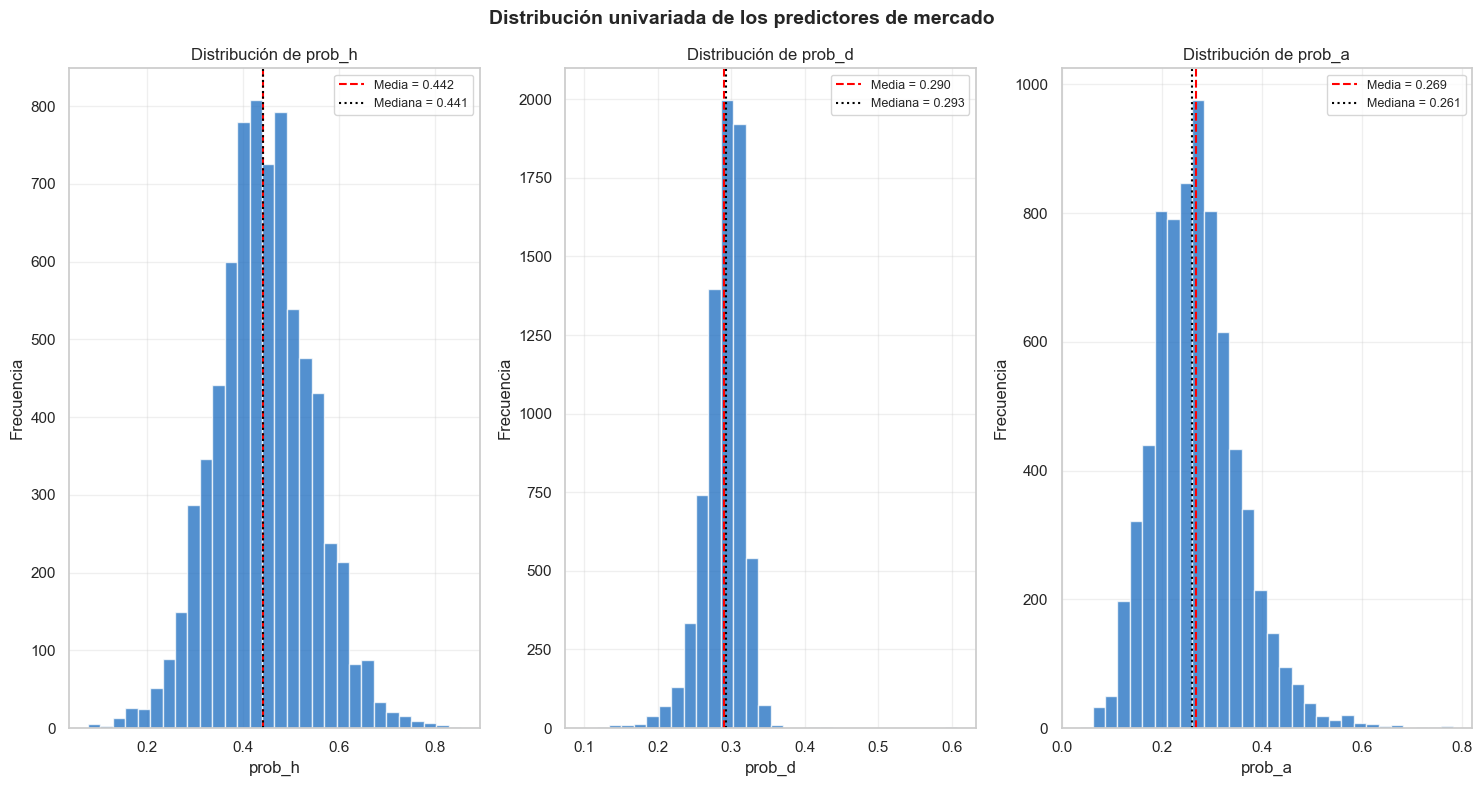

Estadísticos descriptivos:
          prob_h     prob_d     prob_a
count  7295.0000  7295.0000  7295.0000
mean      0.4416     0.2897     0.2687
std       0.0993     0.0272     0.0848
min       0.0763     0.0996     0.0358
25%       0.3756     0.2766     0.2091
50%       0.4411     0.2930     0.2607
75%       0.5079     0.3049     0.3137
max       0.8533     0.6069     0.7828

Asimetría (skewness):
prob_h    0.055
prob_d   -0.596
prob_a    0.769
dtype: float64


In [24]:
predictores = ['prob_h', 'prob_d', 'prob_a']

fig, axes = plt.subplots(1, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(predictores):
    data = matches[col].dropna()
    axes[i].hist(data, bins=30, color="#1a6bbf", edgecolor="white", alpha=0.75)
    axes[i].axvline(data.mean(), color="red", linestyle="--", linewidth=1.5,
                    label=f"Media = {data.mean():.3f}")
    axes[i].axvline(data.median(), color="black", linestyle=":", linewidth=1.5,
                    label=f"Mediana = {data.median():.3f}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Distribución univariada de los predictores de mercado", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Estadísticos descriptivos:")
print(matches[predictores].describe().round(4))
print(f"\nAsimetría (skewness):")
print(matches[predictores].skew().round(3))

La distribución de `prob_h` es aproximadamente simétrica y centrada en 0,442, coherente con la frecuencia base de victorias locales identificada en la sección 2. `prob_a` presenta una asimetría ligera a la derecha (media 0,269), reflejando que la victoria visitante es estructuralmente menos probable por partido.

El hallazgo más destacable del análisis univariado es la **estrechez de la distribución de `prob_d`**, que se concentra casi en su totalidad en el rango 0,20-0,35 con una media de 0,290. El mercado raramente asigna probabilidades de empate fuera de este intervalo, lo que sugiere que como variable predictora aporta poca capacidad discriminatoria por su escasa variabilidad.

### 4.2 Análisis bivariado: predictores vs FTR

Para cada predictor se compara su distribución condicionada al resultado del partido. La separación visible entre las tres clases es indicativa de la capacidad predictiva de la variable: una distribución idéntica entre H, D y A no aporta información discriminatoria, mientras que una separación clara entre clases convierte a la variable en candidata fuerte para el modelado.

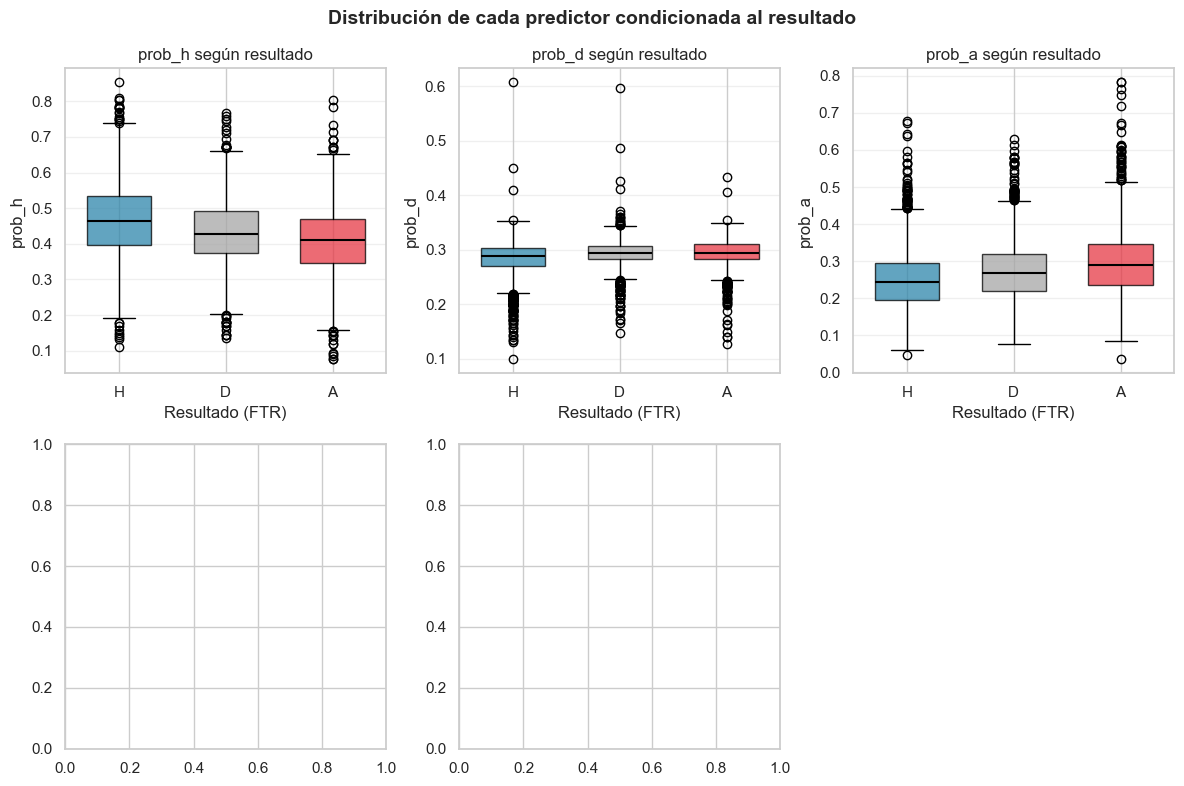


Media de cada predictor por resultado:
     prob_h  prob_d  prob_a
ftr                        
H    0.4658  0.2852  0.2490
D    0.4319  0.2935  0.2746
A    0.4093  0.2933  0.2974


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
orden_ftr = ["H", "D", "A"]

for i, col in enumerate(predictores):
    df_plot = matches[[col, "ftr"]].dropna()
    datos = [df_plot[df_plot["ftr"] == c][col].values for c in orden_ftr]

    bp = axes[i].boxplot(datos, labels=orden_ftr, patch_artist=True, widths=0.6)
    for patch, c in zip(bp["boxes"], orden_ftr):
        patch.set_facecolor(PALETA_FTR[c])
        patch.set_alpha(0.75)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    axes[i].set_xlabel("Resultado (FTR)")
    axes[i].set_ylabel(col)
    axes[i].set_title(f"{col} según resultado")
    axes[i].grid(True, axis="y", alpha=0.3)

axes[5].axis("off")

plt.suptitle("Distribución de cada predictor condicionada al resultado", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nMedia de cada predictor por resultado:")
medias = matches.groupby("ftr")[predictores].mean().round(4)
print(medias)

El análisis bivariado revela diferencias notables en la capacidad discriminatoria de cada predictor.

**Predictores discriminatorios.** `prob_h` muestra el patrón esperado, con medianas que se ordenan A < D < H. `prob_a` exhibe el orden inverso, también consistente.
**Predictores no discriminatorios.** `prob_d` muestra distribuciones prácticamente idénticas entre las tres clases (medias de 0,285 / 0,294 / 0,293 para H, D y A respectivamente), lo que indica que **el mercado no es capaz de identificar a priori los partidos que terminarán en empate**: la probabilidad implícita de empate no varía sistemáticamente entre los encuentros que efectivamente terminan en empate y los que no. Este hallazgo proporciona una explicación estructural a la dificultad sistemática de predecir empates documentada en el capítulo 2: ni siquiera el mercado, que agrega el conocimiento de miles de apostantes profesionales, dispone de una señal predictiva clara para esta clase.

### 4.3 Matriz de correlación

Se calculan las correlaciones de Pearson entre todos los predictores numéricos para identificar redundancias y multicolinealidad. Variables fuertemente correlacionadas aportan información redundante y pueden eliminarse sin pérdida de capacidad predictiva, simplificando el modelo y reduciendo el riesgo de sobreajuste, especialmente en modelos sensibles a la colinealidad como la regresión logística.

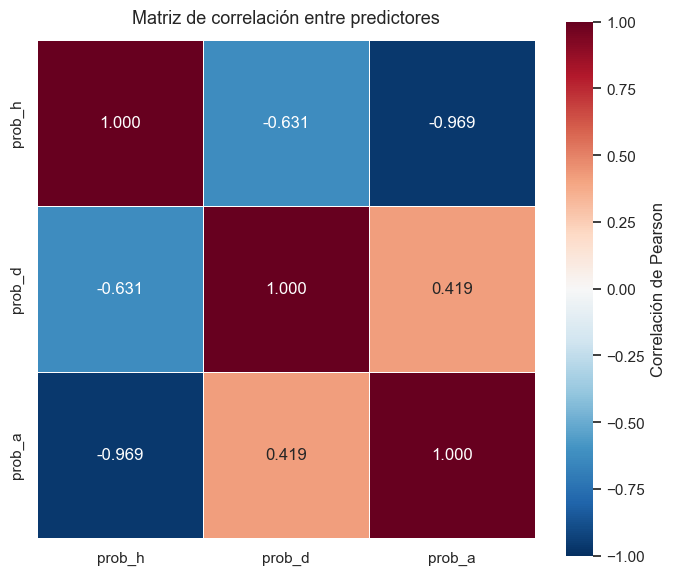


Verificación de la restricción probabilística:
  Media de prob_h + prob_d + prob_a:  1.0000
  Desviación típica:                  0.000000
  Rango: [1.0000, 1.0000]


In [26]:
corr = matches[predictores].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            fmt=".3f", square=True, linewidths=0.5,
            cbar_kws={"label": "Correlación de Pearson"})
ax.set_title("Matriz de correlación entre predictores", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

suma_probs = matches[["prob_h", "prob_d", "prob_a"]].sum(axis=1)
print("\nVerificación de la restricción probabilística:")
print(f"  Media de prob_h + prob_d + prob_a:  {suma_probs.mean():.4f}")
print(f"  Desviación típica:                  {suma_probs.std():.6f}")
print(f"  Rango: [{suma_probs.min():.4f}, {suma_probs.max():.4f}]")

La matriz de correlación revela dos patrones distintos:

**Restricción matemática del mercado 1X2.** `prob_h` y `prob_a` presentan correlación de -0,969, reflejando la restricción `prob_h + prob_d + prob_a = 1`. `prob_d` mantiene correlaciones moderadas con las otras dos (-0,631 y 0,419) por la misma causa.

### 4.4 Implicaciones para el feature engineering

A partir del análisis univariado, bivariado y de correlación, se establecen las siguientes decisiones para la construcción del *dataset* final:

- **Predictores conservados sin reservas.** `prob_h` y `pos_diff` son los predictores más informativos, con clara capacidad discriminatoria y correlación moderada entre sí (-0,638), por lo que ambos aportan señal complementaria. `mv_diff` se mantiene también por su capacidad explicativa, pese a estar correlacionada con los anteriores: las correlaciones por debajo de 0,65 no justifican eliminar variables que aportan poder predictivo demostrado.

- **Variable redundante eliminada.** `prob_a` se descarta. Su correlación con `prob_h` (-0,969) es tan alta que aporta información esencialmente idéntica (con signo invertido). Mantener ambas introduciría multicolinealidad estricta en los modelos lineales.

- **Variable no discriminatoria eliminada.** `prob_d` se descarta como predictor directo. El análisis bivariado confirma que no separa las clases.

- **Atención específica a la clase empate.** Ningún predictor disponible separa la clase D del resto. Esta dificultad se atenuará con la inclusión de variables derivadas en el siguiente *notebook* (medias móviles, sistema Elo, días de descanso) y, sobre todo, mediante el énfasis en las métricas *recall* y *F1-score* de la clase D en la evaluación, según se ha definido en el apartado 3.4 del capítulo 3.

## 5. Línea base externa: el mercado de apuestas

### 5.1 Calibración del mercado

Las cuotas implícitas del mercado son la referencia. 

1. Verificar que el mercado está bien calibrado.
2. Calcular el log-loss del mercado que es el número que los modelos del TFM deben perseguir.

Calibración del mercado de apuestas (gap ≈ 0 = bien calibrado):
               n  prob_h_media  pct_real_H  pct_real_D  expected_score_real    gap
bin                                                                               
(0.0, 0.3]   531         0.253       0.252       0.290                0.397  0.144
(0.3, 0.4]  1976         0.359       0.362       0.327                0.525  0.166
(0.4, 0.5]  2818         0.450       0.458       0.306                0.611  0.162
(0.5, 0.6]  1581         0.543       0.576       0.256                0.704  0.161
(0.6, 0.7]   337         0.635       0.668       0.208                0.772  0.137
(0.7, 1.0]    52         0.743       0.788       0.135                0.856  0.113


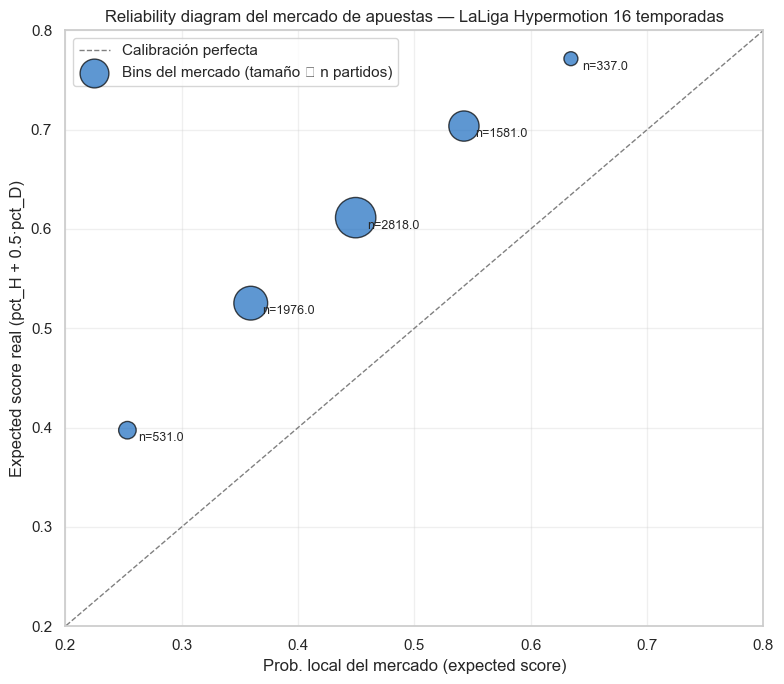

In [27]:
df_v = matches.dropna(subset=["prob_h"]).copy()
df_v["bin"] = pd.cut(df_v["prob_h"], bins=[0, 0.30, 0.40, 0.50, 0.60, 0.70, 1.0])

cal = df_v.groupby("bin", observed=True).agg(
    n=("ftr", "size"),
    prob_h_media=("prob_h", "mean"),
    pct_real_H=("ftr", lambda x: (x == "H").mean()),
    pct_real_D=("ftr", lambda x: (x == "D").mean()),
)
cal["expected_score_real"] = cal["pct_real_H"] + 0.5 * cal["pct_real_D"]
cal["gap"] = (cal["expected_score_real"] - cal["prob_h_media"]).round(3)

print("Calibración del mercado de apuestas (gap ≈ 0 = bien calibrado):")
print(cal.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Calibración perfecta")
ax.scatter(cal["prob_h_media"], cal["expected_score_real"],
           s=cal["n"].values * 0.3, color="#1a6bbf", alpha=0.7,
           edgecolor="black", linewidth=1, label="Bins del mercado (tamaño ∝ n partidos)")
for _, row in cal.iterrows():
    ax.annotate(f"n={row['n']}",
                xy=(row["prob_h_media"], row["expected_score_real"]),
                xytext=(8, -8), textcoords="offset points", fontsize=9)

ax.set_xlim(0.2, 0.8)
ax.set_ylim(0.2, 0.8)
ax.set_xlabel("Prob. local del mercado (expected score)")
ax.set_ylabel("Expected score real (pct_H + 0.5·pct_D)")
ax.set_title("Reliability diagram del mercado de apuestas — LaLiga Hypermotion 16 temporadas")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Log-loss del mercado como benchmark

In [28]:
mask = df_v[["prob_a","prob_d","prob_h"]].notna().all(axis=1)
y_true = df_v.loc[mask, "ftr"].astype(str)
y_pred = df_v.loc[mask, ["prob_a","prob_d","prob_h"]].values
ll_market = log_loss(y_true, y_pred, labels=["A","D","H"])

print(f"Log-loss del mercado (todas las temporadas):  {ll_market:.4f}")

print(f"\nLog-loss del mercado por temporada:")
for season in sorted(df_v["season"].unique()):
    sub = df_v[(df_v["season"] == season) & mask]
    if len(sub) > 0:
        ll = log_loss(sub["ftr"].astype(str),
                      sub[["prob_a","prob_d","prob_h"]].values,
                      labels=["A","D","H"])
        print(f"  {season}-{(season+1)%100:02d}: {ll:.4f}  (n={len(sub)})")

Log-loss del mercado (todas las temporadas):  1.0363

Log-loss del mercado por temporada:
  2010-11: 1.0313  (n=461)
  2011-12: 1.0025  (n=460)
  2012-13: 1.0229  (n=461)
  2013-14: 1.0799  (n=462)
  2014-15: 1.0273  (n=462)
  2015-16: 1.0422  (n=462)
  2016-17: 1.0442  (n=462)
  2017-18: 1.0153  (n=461)
  2018-19: 1.0303  (n=441)
  2019-20: 1.0760  (n=460)
  2020-21: 1.0376  (n=454)
  2021-22: 1.0305  (n=460)
  2022-23: 1.0426  (n=459)
  2023-24: 1.0470  (n=461)
  2024-25: 1.0171  (n=462)
  2025-26: 1.0328  (n=407)


## 6. Resumen ejecutivo

Hallazgos clave del análisis exploratorio de LaLiga *Hypermotion* 2010-11 a 2025-26 (16 temporadas, 7.295 partidos tras la limpieza):

1. **Distribución del resultado.** Ventaja local clara (45,5 % H, 29,4 % D, 25,1 % A), estadísticamente significativa (χ² = 503,26; *p-valor* prácticamente nulo) y estable a lo largo de las 16 temporadas. La temporada 2019-20 presenta una caída notable de la victoria local (χ² = 17,5, el valor más bajo del periodo), coincidiendo con la disputa de partidos sin público durante la pandemia de COVID-19.

2. **Ventaja de campo cuasi-universal.** A nivel de equipo agregado a lo largo de sus temporadas en SP2, solo el Extremadura presenta una ventaja propia negativa, atribuible a su escasa muestra (dos temporadas) y a una mala racha local en su año COVID.

3. **El factor afición pesa.** Los 21 casos anómalos a nivel equipo×temporada (más puntos como visitante que como local) se concentran en (a) temporadas COVID y (b) clubes con estadios reducidos o filiales. Cuando el ambiente desaparece, la ventaja local se diluye.

4. **Lucha por el ascenso muy concentrada.** El ascenso directo se cierra históricamente entre la primera y la cuarta posición tras la jornada 38. Las posiciones séptima y siguientes nunca han remontado al ascenso directo en el periodo analizado.

5. **El dinero importa, pero no lo explica todo.** El valor de mercado de la plantilla correlaciona positivamente con los puntos finales (r = 0,46, R² = 0,21), pero deja un 79 % de varianza sin explicar por presupuesto. Hay margen sustancial para que los modelos aporten valor sobre la línea base presupuestaria.

6. **Capacidad discriminatoria de los predictores disponibles.** El análisis de los cinco predictores disponibles pre-partido revela un patrón claro: `prob_h`, `pos_diff` y `mv_diff` discriminan correctamente las clases H y A, con `pos_diff` como el predictor visualmente más informativo. En cambio, `prob_d` no varía sistemáticamente entre partidos que terminan en empate y los que no, lo que ofrece una explicación estructural a la dificultad histórica de predecir empates: el propio mercado no captura señales predictivas para esta clase.

7. **El mercado de apuestas está bien calibrado.** Las cuotas implícitas predicen el *expected score* con desviaciones inferiores a 0,02 en todos los *bins* del diagrama de calibración. El *log-loss* del mercado, calculado en el apartado 5.2 de este *notebook*, constituye la línea base externa que los modelos del TFM deberán batir.

### 6.1 Implicaciones para el modelado

- **Predictores prioritarios para el siguiente *notebook***: `prob_h`, `pos_diff`, `mv_diff`. La familia D (valor de mercado, capítulo 2) será un predictor potente, pero combinada con la información posicional y de mercado, no en solitario.
- **Variables a descartar**: `prob_a` por redundancia con `prob_h`, `prob_d` por falta de capacidad discriminatoria.
- **Tratamiento de las temporadas COVID**: aislamiento en validación según lo definido en el capítulo 3, complementado eventualmente con una variable indicadora para que los modelos puedan ajustarse al cambio de régimen.
- **Línea base a batir**: el *log-loss* del mercado calculado en 5.2. Cualquier modelo que se quede notablemente por encima no aporta sobre el mercado y debe descartarse.
- **Reto principal del modelado**: la clase empate. El EDA confirma que ni siquiera el mercado lo identifica de forma estructural, lo que sitúa al *recall* y al *F1-score* del empate como métricas centrales de evaluación.

## 7. Persistencia de los datos limpios

Para que los notebooks posteriores no tengan que repetir las operaciones de carga, limpieza y asignación de jornadas, se persisten los cuatro DataFrames principales en formato Parquet en `data/interim/`. Este será el punto de partida del notebook `01_feature_engineering.ipynb`.

In [29]:
interim_dir = Path("data/interim")
interim_dir.mkdir(parents=True, exist_ok=True)

matches.to_parquet(interim_dir / "matches_clean.parquet", index=False)
standings.to_parquet(interim_dir / "standings_clean.parquet", index=False)
squads.to_parquet(interim_dir / "squads_clean.parquet", index=False)
clubs.to_parquet(interim_dir / "clubs_clean.parquet", index=False)

print("Datasets guardados en data/interim/:")
print(f"  matches:   {len(matches):,} filas × {len(matches.columns)} columnas")
print(f"  standings: {len(standings):,} filas × {len(standings.columns)} columnas")
print(f"  squads:    {len(squads):,} filas × {len(squads.columns)} columnas")
print(f"  clubs:     {len(clubs):,} filas × {len(clubs.columns)} columnas")

Datasets guardados en data/interim/:
  matches:   7,295 filas × 36 columnas
  standings: 14,784 filas × 12 columnas
  squads:    10,433 filas × 10 columnas
  clubs:     352 filas × 5 columnas
